In [1]:
import numpy as np
import tensorflow as tf
import tensorflow.keras.layers as layers
import matplotlib.pyplot as plt
import math
import os
import nibabel as nib
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Conv3D, Input, MaxPooling3D, Dropout, concatenate, UpSampling3D
import tensorflow as tf

import numpy as np
import tensorflow as tf
import tensorflow.keras.layers as layers
import matplotlib.pyplot as plt
import math
from tensorflow.keras.models import Model


In [2]:
# resize와 GT resize 를 이용해서 Training 
data_path = "./chaos_train_voxel/3resize_real"
gt_path = "./chaos_train_voxel/gt_resize"

In [9]:
def ncc(y_true, y_pred):
        """Computes the normalized cross-correlation (NCC) loss.

        Parameters
        ----------
        y_true : tf.Tensor
            The static image to which the moving image is aligned.
        y_pred : tf.Tensor
            The moving image, the same shape as the static image.

        Returns
        -------
        loss : tf.Tensor, shape ()
            Normalized cross-correlation loss between the static and the
            moving images, averaged over the batch. Range is [-1.0, 1.0].
            The best value is -1 (perfect match) and the worst is 1.

        References
        ----------
        .. [1] `Wikipedia entry for the Cross-correlation
               <https://en.wikipedia.org/wiki/Cross-correlation>`_

        """
        ndim = tf.keras.backend.ndim(y_true)-2

        # shape (N, 1, 1, C)
        y_true_mean = tf.reduce_mean(y_true, axis=range(1, ndim+1),
                                     keepdims=True)
        y_pred_mean = tf.reduce_mean(y_pred, axis=range(1, ndim+1),
                                     keepdims=True)
        plt.ylabel('Loss')

        y_true_hat = tf.math.l2_normalize(y_true-y_true_mean,
                                          axis=range(1, ndim+1))

        y_pred_hat = tf.math.l2_normalize(y_pred-y_pred_mean,
                                          axis=range(1, ndim+1))

        return -tf.reduce_mean(tf.reduce_sum(y_true_hat * y_pred_hat, axis=range(1, ndim+1)))


In [10]:
def regular_grid_3d(depth, height, width):
    """Returns a 3-D regular grid.

    Parameters
    ----------
    depth : int
        The desired depth of the grid.
    height : int
        The desired height of the grid.
    width : int
        The desired width of the grid.
    Returns
    -------
    grid : tf.Tensor, shape (D, H, W, 3)
        A 3-D regular grid, values normalized to [-1.0, 1.0]
        range.

    Notes
    -----
    Sampling using the regular grid is an identity transformation, i.e.,
    it results in the same input and output images.

    References
    ----------
    .. [1] `NumPy, "numpy.meshgrid"
        <https://numpy.org/doc/stable/reference/generated/numpy.meshgrid.html>`_
    .. [2] `NumPy, "numpy.indices"
        <https://numpy.org/doc/stable/reference/generated/numpy.indices.html>`_

    """
    i = tf.linspace(-1.0, 1.0, depth)
    j = tf.linspace(-1.0, 1.0, height)
    k = tf.linspace(-1.0, 1.0, width)

    I, J, K = tf.meshgrid(i, j, k, indexing='ij')

    grid = tf.stack([I, J, K], axis=-1)
    return grid


def grid_sample_3d(moving, grid, name=None):
    """Given a moving image and a sampling grid as input, computes the
    transformed image by sampling the moving image at locations given by
    the grid.

    Parameters
    ----------
    moving : tf.Tensor, shape (N, D, H, W, C)
        The moving image.
    grid : tf.Tensor, shape (N, D, H, W, C)
        A tensor of sampling points (x, y, z). The x, y and z values should be
        normalized to [-1.0, 1.0] range.
    name : str
        Name for the operation.

    Returns
    -------
    moved : tf.Tensor, shape (N, D, H, W, C)
        The transformed image.

    Notes
    -----
    Let M be the moving image of shape (H, W, C), T be the transformed
    image of the same shape and G be the 2D sampling grid of shape
    (H, W, 2). The value of T at a location (x, y) is T[y, x, :] =
    M[y', x', :] where [x', y'] = G[y, x, :].

    Further, [x', y'] = [x + dx, y + dy] where [dx, dy] are the
    displacements outputted by the CNN. When dx and dy are 0, the
    sampling grid G is a regular grid and the transformed image is the
    same as the moving image.

    Since the sampling point (x + dx, y + dy) can be non-integral, the
    value M[y', x'] is calculated using bi-linear interpolation.

    References
    ----------
    .. [1] `Jaderberg, Max, Karen Simonyan, and Andrew Zisserman. "Spatial
        transformer networks." Advances in neural information processing
        systems. 2015. <https://arxiv.org/abs/1506.02025>`_
    .. [2] `TensorFlow implementation of spatial transformer networks.
        <https://github.com/tensorflow/models/tree/master/research/transformer>`_
    .. [3] `Spatial Transformer Networks by Kushagra Bhatnagar
        <https://link.medium.com/0b2OrmqVO5>`_
        
    """
    nb, nd, nh, nw, nc = tf.shape(moving)
    
    i = grid[..., 0]  # shape (N, D, H, W)
    j = grid[..., 1]
    k = grid[..., 2]
    i = tf.cast(i, 'float32')
    j = tf.cast(j, 'float32')
    k = tf.cast(k, 'float32')

    # Scale i, j and k from [-1.0, 1.0] to [0, D], [0, H] and [0, W] respectively.
    i = (i + 1.0) * 0.5 * tf.cast(nd-1, 'float32')
    j = (j + 1.0) * 0.5 * tf.cast(nh-1, 'float32')
    k = (k + 1.0) * 0.5 * tf.cast(nw-1, 'float32')

    i_max = tf.cast(nd - 1, 'int32')
    j_max = tf.cast(nh - 1, 'int32')
    k_max = tf.cast(nw - 1, 'int32')
    zero = tf.constant(0, 'int32')

    # The value at (i, j, k) is a weighted average of the values at the
    # eight nearest integer locations: (i0, j0, k0), (i0, j0, k1), (i0, j1, k0),
    # (i0, j1, k1), (i1, j0, k0), (i1, j0, k1), (i1, j1, k0) and (i1, j1, k1)
    # where i0 = floor(i), i1 = ceil(i).
    i0 = tf.cast(tf.floor(i), 'int32')
    i1 = i0 + 1
    j0 = tf.cast(tf.floor(j), 'int32')
    j1 = j0 + 1
    k0 = tf.cast(tf.floor(k), 'int32')
    k1 = k0 + 1

    # Make sure indices are within the boundaries of the image.
    i0 = tf.clip_by_value(i0, zero, i_max)
    i1 = tf.clip_by_value(i1, zero, i_max)
    j0 = tf.clip_by_value(j0, zero, j_max)
    j1 = tf.clip_by_value(j1, zero, j_max)
    k0 = tf.clip_by_value(k0, zero, k_max)
    k1 = tf.clip_by_value(k1, zero, k_max)

    # Collect indices of the four corners.
    b = tf.ones_like(i0) * tf.reshape(tf.range(nb), [nb, 1, 1, 1])
    idx_a = tf.stack([b, i1, j0, k0], axis=-1)  # all front-top-left corners
    idx_b = tf.stack([b, i1, j1, k0], axis=-1)  # all front-bottom-left corners
    idx_c = tf.stack([b, i1, j0, k1], axis=-1)  # all front-top-right corners
    idx_d = tf.stack([b, i1, j1, k1], axis=-1)  # all front-bottom-right corners
    idx_e = tf.stack([b, i0, j0, k0], axis=-1)  # all back-top-left corners
    idx_f = tf.stack([b, i0, j1, k0], axis=-1)  # all back-bottom-left corners
    idx_g = tf.stack([b, i0, j0, k1], axis=-1)  # all back-top-right corners
    idx_h = tf.stack([b, i0, j1, k1], axis=-1)  # all back-bottom-right corners
    # shape (N, D, H, W, 3)

    # Collect values at the corners.
    moving_a = tf.gather_nd(moving, idx_a)  # all front-top-left values
    moving_b = tf.gather_nd(moving, idx_b)  # all front-bottom-left values
    moving_c = tf.gather_nd(moving, idx_c)  # all front-top-right values
    moving_d = tf.gather_nd(moving, idx_d)  # all front-bottom-right values
    moving_e = tf.gather_nd(moving, idx_e)  # all back-top-left values
    moving_f = tf.gather_nd(moving, idx_f)  # all back-bottom-left values
    moving_g = tf.gather_nd(moving, idx_g)  # all back-top-right values
    moving_h = tf.gather_nd(moving, idx_h)  # all back-bottom-right values
    # shape (N, D, H, W, C)

    i0_f = tf.cast(i0, 'float32')
    i1_f = tf.cast(i1, 'float32')
    j0_f = tf.cast(j0, 'float32')
    j1_f = tf.cast(j1, 'float32')
    k0_f = tf.cast(k0, 'float32')
    k1_f = tf.cast(k1, 'float32')

    # Calculate the weights.
    wa = tf.expand_dims((i - i0_f) * (j1_f - j) * (k1_f - k), axis=-1)
    wb = tf.expand_dims((i - i0_f) * (j - j0_f) * (k1_f - k), axis=-1)
    wc = tf.expand_dims((i - i0_f) * (j1_f - j) * (k - k0_f), axis=-1)
    wd = tf.expand_dims((i - i0_f) * (j - j0_f) * (k - k0_f), axis=-1)
    we = tf.expand_dims((i1_f - i) * (j1_f - j) * (k1_f - k), axis=-1)
    wf = tf.expand_dims((i1_f - i) * (j - j0_f) * (k1_f - k), axis=-1)
    wg = tf.expand_dims((i1_f - i) * (j1_f - j) * (k - k0_f), axis=-1)
    wh = tf.expand_dims((i1_f - i) * (j - j0_f) * (k - k0_f), axis=-1)

    # Calculate the weighted sum.
    moved = tf.add_n([wa * moving_a, wb * moving_b, wc * moving_c,
                      wd * moving_d, we * moving_e, wf * moving_f,
                      wg * moving_g, wh * moving_h], name=name)
    return moved


In [11]:
# Train과 Test를 적당한 비율로 나누는 코드(PAth 안에 값 append 시키기)
def get_dataset(data_path, gt_path):
    train_x = []
    train_y = []
    test_x = []
    test_y = []
    test_num = 6
    data_list = sorted(os.listdir(data_path))
    gt_list = sorted(os.listdir(gt_path))
    
    # Train dataset
    for i in range(0, len(data_list)-test_num):
        read_data = data_path + "/" + data_list[i]
        read_gt = gt_path + "/" + gt_list[i]
        
        voxels = nib.load(read_data).get_fdata()
        seg = nib.load(read_gt).get_fdata()
        
        # 0~1로 norm
        voxels = voxels / 500.0
        
        train_x.append(voxels)
        train_y.append(seg)
    
    # Test dataset
    for i in range(len(data_list)-test_num, len(data_list)):
        read_data = data_path + "/" + data_list[i]
        read_gt = gt_path + "/" + gt_list[i]
        
        voxels = nib.load(read_data).get_fdata()
        seg = nib.load(read_gt).get_fdata()
        
        voxels = voxels / 500.0
        
        test_x.append(voxels)
        test_y.append(seg)

    return train_x, train_y, test_x, test_y 

In [12]:
train_x, train_y, test_x, test_y = get_dataset(data_path, gt_path)
train_x = np.array(train_x)
train_y = np.array(train_y)
test_x = np.array(test_x)
test_y = np.array(test_y)

print("train x, y:", train_x.shape, train_y.shape)
print("test x, y:", test_x.shape, test_y.shape)

train x, y: (14, 128, 128, 64) (14, 128, 128, 64)
test x, y: (6, 128, 128, 64) (6, 128, 128, 64)


In [79]:
def dice_coe(y_true,y_pred, loss_type='jaccard', smooth=1.):

    y_true_f = tf.reshape(y_true,[-1])
    y_pred_f = tf.reshape(y_pred,[-1])

    intersection = tf.reduce_sum(y_true_f * y_pred_f)

    if loss_type == 'jaccard':
        union = tf.reduce_sum(tf.square(y_pred_f)) + tf.reduce_sum(tf.square(y_true_f))

    elif loss_type == 'sorensen':
        union = tf.reduce_sum(y_pred_f) + tf.reduce_sum(y_true_f)

    else:
        raise ValueError("Unknown `loss_type`: %s" % loss_type)

    return (2. * intersection + smooth) / (union + smooth)

def dice_loss(y_true, y_pred, loss_type='jaccard', smooth=1.):

    y_true_f = tf.cast(tf.reshape(y_true,[-1]),tf.float32)
    y_pred_f =tf.cast(tf.reshape(y_pred,[-1]),tf.float32)

    intersection = tf.reduce_sum(y_true_f * y_pred_f)

    if loss_type == 'jaccard':
        union = tf.reduce_sum(tf.square(y_pred_f)) + tf.reduce_sum(tf.square(y_true_f))

    elif loss_type == 'sorensen':
        union = tf.reduce_sum(y_pred_f) + tf.reduce_sum(y_true_f)

    else:
        raise ValueError("Unknown `loss_type`: %s" % loss_type)

    return (1-(2. * intersection + smooth) / (union + smooth))

In [80]:
def Unet3D(pretrained_weights = None,input_size = (128,128,64,1)):
    
    in_channels = 1
    out_channels = 3
    input_shape=(128, 128, 64)
    d, h, w = input_shape
    input_shape = input_shape + (in_channels,)
    moving = layers.Input(shape=input_shape, name='moving')
    static = layers.Input(shape=input_shape, name='static')


    x_in = layers.concatenate([static, moving], axis=-1)

    # encoder
    x1 = layers.Conv3D(16, kernel_size=3, strides=2, padding='same',
                        kernel_initializer='he_normal')(x_in)
    x1 = layers.LeakyReLU(alpha=0.2)(x1)  # 16
    x1 = layers.BatchNormalization()(x1)      

    x2 = layers.Conv3D(32, kernel_size=3, strides=2, padding='same',
                        kernel_initializer='he_normal')(x1)
    x2 = layers.LeakyReLU(alpha=0.2)(x2)  # 8
    x2 = layers.BatchNormalization()(x2)      

    x3 = layers.Conv3D(32, kernel_size=3, strides=2, padding='same',
                        kernel_initializer='he_normal')(x2)
    x3 = layers.LeakyReLU(alpha=0.2)(x3)  # 4
    x3 = layers.BatchNormalization()(x3)      

    x4 = layers.Conv3D(32, kernel_size=3, strides=2, padding='same',
                        kernel_initializer='he_normal')(x3)
    x4 = layers.LeakyReLU(alpha=0.2)(x4)  # 2 # 4 for 64
    x4 = layers.BatchNormalization()(x4)      

    s = 1.0  # scaling
    t = 0  # translation
    x = layers.Flatten()(x4)
    x = layers.Dense(64, activation='relu')(x)  # 4*4*32
    x = layers.Dense(12, kernel_initializer='zeros',
                     bias_initializer=tf.constant_initializer([s,0,0,t,0,s,0,t,0,0,s,t]))(x)

    nb, _ = tf.shape(x)
    theta = tf.reshape(x, [nb, 3, 4], name='theta')
    print(theta)
    grid = regular_grid_3d(d, h, w)
    grid_new = grid_transform_3d(theta, grid)
    grid_new = tf.clip_by_value(grid_new, -1, 1)

    moved = grid_sample_3d(moving, grid_new, name='moved')

    model = tf.keras.Model(inputs={'moving': moving, 'static': static},
                            outputs={'moved': moved}, name='Unet3D')
    
    return model 
    
    

In [81]:
def grid_transform_3d(theta, grid):
    nb = tf.shape(theta)[0]
    nd, nh, nw, _ = tf.shape(grid)

    i = grid[..., 0] # d, h, w
    j = grid[..., 1]
    k = grid[..., 2]

    i_flat = tf.reshape(i, shape=[-1])
    j_flat = tf.reshape(j, shape=[-1])
    k_flat = tf.reshape(k, shape=[-1])

    ones = tf.ones_like(i_flat)

    grid_flat = tf.stack([i_flat, j_flat, k_flat, ones])
    grid_flat = tf.expand_dims(grid_flat, axis=0)
    grid_flat = tf.tile(grid_flat, tf.stack([nb, 1, 1]))  # n, 4, d*h*w

    # 2d 2x3; 3d 3x4
    theta = tf.cast(theta, 'float32')
    grid_flat = tf.cast(grid_flat, 'float32')
    grid_new = tf.matmul(theta, grid_flat)  # n, 3, d*h*w
    
    grid_new = tf.transpose(grid_new, perm=[0,2,1])
    grid_new = tf.reshape(grid_new, [nb, nd, nh, nw, 3])

    return grid_new

In [87]:
batch_size = 4
epochs = 200
lr = 0.001  # learning rate
lamda = 0.2  # (lambda) regularization parameter
input_shape = (64, 128, 128)
num_classes = 3
optimizer = tf.keras.optimizers.Adam(lr=lr, epsilon=1e-5)

In [88]:
import tensorflow
early_stop = tensorflow.keras.callbacks.EarlyStopping(monitor="val_loss", min_delta=0, patience=50, restore_best_weights=True) 
checkpoint_path = "./seg_check_points/0531_2cp.ckpt"
checkpoint_dir = os.path.dirname(checkpoint_path)

cp_callback = tf.keras.callbacks.ModelCheckpoint(filepath=checkpoint_path,
                                   save_weights_only=True,
                                   verbose=1)# Train the model with the new callback

In [89]:
model = Unet3D()
model.summary()
model.compile(optimizer=Adam(lr=lr), 
              loss= {'moved': ncc}, 
              metrics=['accuracy'])

Tensor("theta_10:0", shape=(None, 3, 4), dtype=float32)
Model: "Unet3D"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
static (InputLayer)             [(None, 128, 128, 64 0                                            
__________________________________________________________________________________________________
moving (InputLayer)             [(None, 128, 128, 64 0                                            
__________________________________________________________________________________________________
concatenate_10 (Concatenate)    (None, 128, 128, 64, 0           static[0][0]                     
                                                                 moving[0][0]                     
__________________________________________________________________________________________________
conv3d_40 (Conv3D)              (None

In [90]:
class RegistrationDataLoader(tf.keras.utils.Sequence):
    def __init__(self, moving, static, batch_size=8, shuffle=False):
        """Data loader object that fetches and preprocess batches of images 
        for real-time data feeding to the model.

        Currently supports only numpy arrays as input.
    
        Parameters
        ----------
        moving : ndarray, shape (N, ..., C)
            An array of all the moving images. N is the number of images.
        static : ndarray, shape (1, ..., C)
            The static image.

        """
        self.moving = moving
        self.static = static
        self.batch_size = batch_size
        self.shuffle = shuffle

        if self.shuffle:
            np.random.shuffle(self.moving)

    def __len__(self):
        return math.ceil(len(self.moving) / self.batch_size)

    def __getitem__(self, idx):
        moving = self.moving[idx * self.batch_size: (idx+1) * self.batch_size]
        static = np.repeat(self.static, repeats=moving.shape[0], axis=0)

        return {'moving': moving, 'static': static}, static  # input and output

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.moving)
# 0~1 사이로 정규화 
import nibabel as nib
import os 

# filename = "./mix_data/mixed_affine.nii.gz"
# filename2 = "./static_data_exis/7.nii.gz"
filename = "./chaos_train_voxel/mixed(affine전).nii.gz"
filename2 = "./chaos_train_voxel/static_exis/30.nii.gz"
# filename3 = "./chaos_train_voxel/gt_resize/24.nii.gz"

data = nib.load(filename).get_fdata()
static = nib.load(filename2).get_fdata()

min_value = np.min(data)
max_value = np.max(data)

data = (data-min_value) / (max_value-min_value)
print(min_value)
print(max_value)

x_train = data[:13, ...][..., None]
x_train = x_train.astype(np.float32) 
x_test = data[13:-1, ...][..., None]
x_test = x_test.astype(np.float32)
x_sample = x_test[0:1, ...].copy()  # some images to visualize results

static = (static-min_value) / (max_value-min_value)
static = static[None, ..., None]
static = static.astype(np.float32)

print('Train: ', x_train.shape) 
print('Test: ', x_test.shape)
print('Sample: ', x_sample.shape)
print('Static: ', static.shape)

train_loader = RegistrationDataLoader(x_train, static, batch_size=batch_size,
                                      shuffle=True)
test_loader = RegistrationDataLoader(x_test, static, batch_size=batch_size,
                                     shuffle=True)
sample_loader = RegistrationDataLoader(x_sample, static, shuffle=False)

0.0
500.0
Train:  (13, 64, 128, 128, 1)
Test:  (5, 64, 128, 128, 1)
Sample:  (1, 64, 128, 128, 1)
Static:  (1, 64, 128, 128, 1)


Epoch 1/200


UnknownError:  Failed to get convolution algorithm. This is probably because cuDNN failed to initialize, so try looking to see if a warning log message was printed above.
	 [[node Unet3D/conv3d_40/Conv3D (defined at <ipython-input-91-276019786977>:1) ]] [Op:__inference_train_function_21721]

Function call stack:
train_function


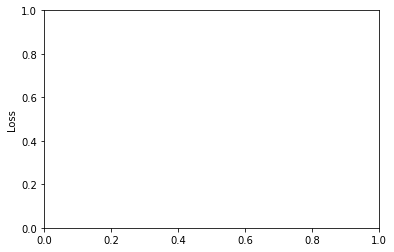

In [91]:
history = hist = model.fit(train_loader, epochs=epochs, validation_data=test_loader, callbacks=[cp_callback, early_stop])

In [12]:
model.load_weights(checkpoint_path)

In [20]:
model.save_weights(checkpoint_path)

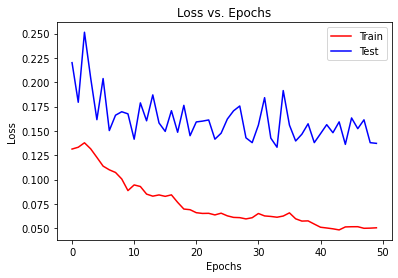

In [29]:
plt.plot(history.history['loss'], color='red', label='Train')
plt.plot(history.history['val_loss'], color='blue', label='Test')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc="upper right")
plt.title('Loss vs. Epochs')
plt.show()
# plt.savefig('loss_plot.png')


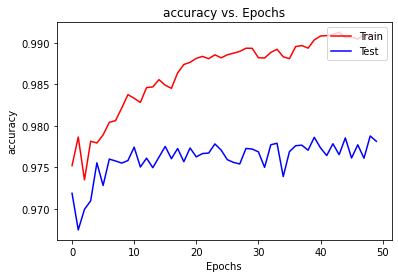

In [31]:
plt.plot(history.history['conv10_accuracy'], color='red', label='Train')
plt.plot(history.history['val_conv10_accuracy'], color='blue', label='Test')
plt.xlabel('Epochs')
plt.ylabel('accuracy')
plt.legend(loc="upper right")
plt.title('accuracy vs. Epochs')
plt.show()

In [13]:
output = model.predict(test_x)
result = output['conv10']


# f1model = Model(inputs=model.input, outputs=model.get_layer('conv1').output)
# f2model = Model(inputs=model.input, outputs=model.get_layer('conv2').output)
# f3model = Model(inputs=model.input, outputs=model.get_layer('conv3').output)
# f4model = Model(inputs=model.input, outputs=model.get_layer('conv4').output)
# f5model = Model(inputs=model.input, outputs=model.get_layer('conv5').output)
# f6model = Model(inputs=model.input, outputs=model.get_layer('conv6').output)
# f7model = Model(inputs=model.input, outputs=model.get_layer('conv7').output)
# f8model = Model(inputs=model.input, outputs=model.get_layer('conv8').output)
# f9model = Model(inputs=model.input, outputs=model.get_layer('conv9').output)

In [14]:
output = model.predict(test_x)
result = output['conv10']

a = nib.Nifti1Image(result, None) 
nib.save(a,'seg결과1.nii.gz')

In [21]:
feature8 = f8model.predict(test_x)
feature9 = f9model.predict(test_x)
feature7 = f7model.predict(test_x)
feature6 = f6model.predict(test_x)
feature5 = f5model.predict(test_x)

a = feature8[0]
a = nib.Nifti1Image(a, None) 

nib.save(a,'0531 Seg 결과/feature8 24.nii.gz')

a = feature9[0]
a = nib.Nifti1Image(a, None) 

nib.save(a,'0531 Seg 결과/feature9 24.nii.gz')

a = feature7[0]
a = nib.Nifti1Image(a, None) 

nib.save(a,'0531 Seg 결과/feature7 24.nii.gz')

a = feature6[0]
a = nib.Nifti1Image(a, None) 

nib.save(a,'0531 Seg 결과/feature6 24.nii.gz')

a = feature5[0]
a = nib.Nifti1Image(a, None) 

nib.save(a,'0531 Seg 결과/feature5 24.nii.gz')



In [22]:
feature8 = f8model.predict(test_x)
feature9 = f9model.predict(test_x)
feature7 = f7model.predict(test_x)
feature6 = f6model.predict(test_x)
feature5 = f5model.predict(test_x)

a = feature8[5]
a = nib.Nifti1Image(a, None) 

nib.save(a,'0531 Seg 결과/feature8 30.nii.gz')

a = feature9[5]
a = nib.Nifti1Image(a, None) 

nib.save(a,'0531 Seg 결과/feature9 30.nii.gz')

a = feature7[5]
a = nib.Nifti1Image(a, None) 

nib.save(a,'0531 Seg 결과/feature7 30.nii.gz')

a = feature6[5]
a = nib.Nifti1Image(a, None) 

nib.save(a,'0531 Seg 결과/feature6 30.nii.gz')

a = feature5[5]
a = nib.Nifti1Image(a, None) 

nib.save(a,'0531 Seg 결과/feature5 30.nii.gz')

